In [ ]:
import os
from google.colab import files

if os.path.exists('/root/.kaggle'):
    !rm -rf /root/.kaggle
    print("Configuración anterior borrada.")


uploaded = files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



# Descargamos el dataset
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
import os

# ==========================================
# CONFIGURACIÓN "LIGERA" PARA AHORRAR RAM
# ==========================================
# Reducimos el tamaño del lote (batch) a la mitad
batch_size = 16
# Hacemos las imágenes más pequeñas (menos píxeles = menos memoria)
img_height = 128
img_width = 128

# Verificamos la ruta (igual que antes)
if os.path.exists('PlantVillage'):
    data_dir = pathlib.Path("PlantVillage")
    print("✅ Carpeta encontrada.")
else:
    data_dir = pathlib.Path(".")
    print("⚠️ Usando ruta actual.")

# ==========================================
# CARGA DE DATOS OPTIMIZADA
# ==========================================
print("Cargando set de entrenamiento...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

print("Cargando set de validación...")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Clases detectadas: {len(class_names)}")

# IMPORTANTE: Esto ayuda a gestionar la memoria dinámicamente
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# MODELO (Ajustado al nuevo tamaño)
# ==========================================
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# ==========================================
# ENTRENAMIENTO
# ==========================================
print(" Iniciando entrenamiento ligero...")
# Reducimos a 5 épocas para probar estabilidad primero
epochs = 5
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

print(" ¡Entrenamiento finalizado!")

✅ Carpeta encontrada.
Cargando set de entrenamiento...
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Cargando set de validación...
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Clases detectadas: 15
 Iniciando entrenamiento ligero...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 294s 261ms/step - accuracy: 0.5052 - loss: 1.5646 - val_accuracy: 0.8076 - val_loss: 0.5687
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 267s 258ms/step - accuracy: 0.8471 - loss: 0.4569 - val_accuracy: 0.8449 - val_loss: 0.4619
Epoch 3/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 321s 257ms/step - accuracy: 0.9103 - loss: 0.2643 - val_accuracy: 0.8990 - val_loss: 0.3077
Epoch 4/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 271s 263ms/step - accuracy: 0.9393 - loss: 0.1797 - val_accuracy: 0.9016 - val_loss: 0.3356
Epoch 5/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 317s 258ms/step - accuracy: 0.9637 - loss: 0.1124 - val_accuracy: 0.8779 - val_loss: 0.4177
 ¡Entrenamiento finalizado!


 ¡Modelo guardado exitosamente como 'modelo_plantas_samsung.keras'!

🔍 Realizando una prueba de diagnóstico...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


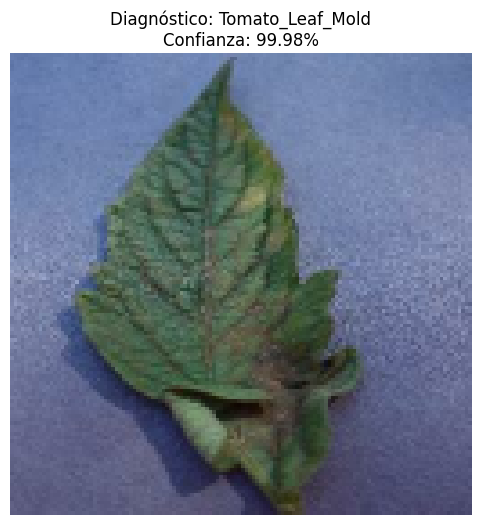

--- RESULTADO ---
La IA dice que es: Tomato_Leaf_Mold
La planta es realmente: Tomato_Leaf_Mold
✅ ¡PREDICCIÓN CORRECTA!


In [ ]:

# ==========================================
# GUARDAR EL MODELO
# ==========================================
# Guardamos el cerebro entrenado en un archivo .keras
model.save('modelo_plantas_samsung.keras')
print(" ¡Modelo guardado exitosamente como 'modelo_plantas_samsung.keras'!")

# ==========================================
#  PRUEBA DE DIAGNÓSTICO REAL
# ==========================================
# Vamos a tomar una imagen aleatoria del set de validación para probar
print("\n🔍 Realizando una prueba de diagnóstico...")

# Tomamos un lote de imágenes de prueba
image_batch, label_batch = next(iter(val_ds))
first_image = image_batch[0].numpy().astype("uint8")
first_label = label_batch[0]

# Hacemos la predicción
# Necesitamos expandir las dimensiones porque el modelo espera un lote
img_array = tf.expand_dims(image_batch[0], 0)
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

# Mostramos el resultado
plt.figure(figsize=(6, 6))
plt.imshow(first_image)
plt.axis("off")

clase_predicha = class_names[np.argmax(score)]
confianza = 100 * np.max(score)
clase_real = class_names[first_label]

plt.title(f"Diagnóstico: {clase_predicha}\nConfianza: {confianza:.2f}%")
plt.show()

print(f"--- RESULTADO ---")
print(f"La IA dice que es: {clase_predicha}")
print(f"La planta es realmente: {clase_real}")

if class_names[np.argmax(score)] == class_names[first_label]:
    print("✅ ¡PREDICCIÓN CORRECTA!")
else:
    print("❌ Falló esta vez (es normal que pase a veces)")

In [ ]:
%%writefile app.py
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import time

# Configuración de página
st.set_page_config(page_title="Agrosense Detector", page_icon="🌿")

# Título
st.title("🌿 Agrosense Detector")
st.markdown("### Sistema de Diagnóstico de Enfermedades en Plantas")


# CARGA DEL MODELO (CON BARRA DE PROGRESO)
# Usamos un contenedor para avisar al usuario
status_text = st.empty()
status_text.text("⏳ Iniciando motores de IA...")

@st.cache_resource
def load_model():
    # Simulamos una pequeña espera para dar feedback visual si es muy rápido
    model = tf.keras.models.load_model('modelo_plantas_samsung.keras')
    return model

try:
    model = load_model()
    status_text.success("✅ Sistema Agrosense Activado y Listo.")
    time.sleep(1) # Un segundo para que veas el mensaje de éxito
    status_text.empty() # Borramos el mensaje para limpiar la pantalla
except Exception as e:
    status_text.error(f"Error cargando el modelo: {e}")

# --- LISTA DE PLANTAS ---
class_names = ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
# --- INTERFAZ DE USUARIO ---
st.write("---")
col1, col2 = st.columns([1, 1])

with col1:
    st.info("Sube una imagen para comenzar el análisis.")
    file = st.file_uploader("Seleccionar archivo", type=["jpg", "png", "jpeg"])

if file is not None:
    # Mostramos la imagen en la segunda columna
    image = Image.open(file)
    with col2:
        st.image(image, caption="Imagen cargada", use_container_width=True)

    # --- BOTÓN DE DIAGNÓSTICO ---
    # Lo ponemos bien grande y visible
    st.write("---")
    if st.button("🔍 ANALIZAR ENFERMEDAD", use_container_width=True, type="primary"):
        with st.spinner('🔬 Agrosense está analizando la hoja...'):
            # Preprocesamiento
            img = image.resize((128, 128))
            img_array = tf.keras.utils.img_to_array(img)
            img_array = tf.expand_dims(img_array, 0)

            # Predicción
            predictions = model.predict(img_array)
            score = tf.nn.softmax(predictions[0])

            resultado = class_names[np.argmax(score)]
            confianza = 100 * np.max(score)

            # --- RESULTADOS ---
            st.success(f"### Resultado: {resultado}")

            # Barra de confianza
            st.progress(int(confianza))
            st.caption(f"Certeza del diagnóstico: {confianza:.2f}%")

            if confianza < 70:
                st.warning("⚠️ La confianza es baja. Podría no ser exacto.")

Overwriting app.py


In [ ]:
# Instalamos la herramienta del túnel
print("🛠️ Instalando herramientas necesarias...")
!npm install -g localtunnel

# Obtenemos tu contraseña (IP)
print("\n👇 COPIA ESTOS NÚMEROS (Es tu contraseña):")
!wget -q -O - ipv4.icanhazip.com

# Iniciamos la App
print("\n👉 ESPERA un momento. Abajo aparecerá un enlace que dice 'your url is: https://...loca.lt'")
!streamlit run app.py & npx localtunnel --port 8501

🛠️ Instalando herramientas necesarias...
⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
👇 COPIA ESTOS NÚMEROS (Es tu contraseña):
34.61.59.163

👉 ESPERA un momento. Abajo aparecerá un enlace que dice 'your url is: https://...loca.lt'
⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://shaky-items-rush.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.61.59.163:8501

2025-12-13 16:39:00.082135: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765643940.107873   30198 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765643940.115511   30198 cuda_blas.cc:1407] Unable to register cuBLAS fa